Итак, приступим к выполнению задачи. В качестве анализируемых данных вам доступнен датасет с симуляцией распадов тяжелых $B_c^+$ мезонов. Симуляция была получена с использованием функции плотности вероятности реального расспределения из данных эксперимента на БАК.

В задании вам будет необходимо выполнить несколько шагов для получения ответа.
Для каждой подзадачи будут даны фрагменты кода, которые вам необходимо будет дополнить + краткое описание в текстовых ячейках. Основная задача заключается в оценке числа сигнальных распадов исследуемой частицы.



Сперва загрузим подготовленный датасет

In [112]:
# работает через direct_url
# standart_url = 'https://drive.google.com/file/d/1g87nRNE1Oi_FnnVfB5h5dCsmYcSfswXW/view?usp=drive_link'
direct_url = 'https://drive.google.com/uc?export=view&id=1H-S-QobJjAYlWo_i9jJ01F2A7oizgRdi'

# data_load = pd.read_csv(direct_url)

Импортируем библиотеки, необходимые для работы



In [113]:
#Импортируем библиотеки

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

Читаем данные и выполняем первую подзадачу - оцениваем диапазон, в котором распределены события

In [114]:
# Загрузка данных из CSV-файла
data = pd.read_csv(direct_url)
mass_data = data['mass'].values

#Оцените интервал, в котором распределены события. Используйте значения, округленные до 2х знаков после запятой


In [73]:
data['mass'].describe()

count    14913.000000
mean         6.281492
std          0.067034
min          6.150002
25%          6.248073
50%          6.274870
75%          6.307840
max          6.449998
Name: mass, dtype: float64

In [74]:
mass_range = mass_data.max() - mass_data.min()
mass_range

0.29999577820890355

Определим остальные параметры гистограммы. Здесь вам предстоит определить:


*   Какое количество бинов должно быть в определенном ранее интервале, если ширина бина равна $0.005~ГэВ/c^2$ ($ГэВ/c^2$ - это мера массы реконструированных частиц)
*   Построить распределение с определенными характеристиками: диапазон, число бинов и их ширина

In [107]:
bin_width = 0.005
low = mass_data.min()
high = mass_data.max()
n_bins = np.int32(round(mass_range / 0.005, 0))

counts, bin_edges = np.histogram(mass_data, bins=n_bins, range=(low, high))


In [108]:
#Определяем параметры гистограммы (значения в столбцах гистограммы и их края)
# counts, bin_edges = np.histogram(mass_data, bins=bins, range=(mass_data.min(), mass_data.max()))

#Вычислям центры каждого бина
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#Вычисляем их ширину (должна совпалать со значением из условия задачи)
bin_width = round(bin_edges[1] - bin_edges[0], 3)

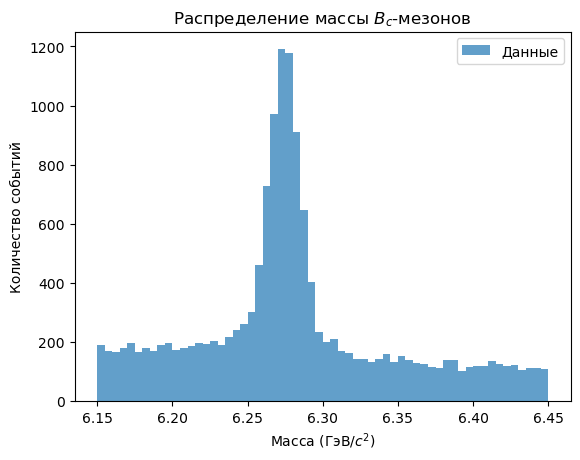

In [109]:
# Нарисуйте гистограмму, с вышеуказанными параметрами

#Ваш код здесь
plt.hist(mass_data, bins=n_bins, range=(low, high), alpha=0.7, label='Данные')

# Для удобства визуализации
plt.xlabel('Масса (ГэВ/$c^2$)')
plt.ylabel('Количество событий')
plt.title('Распределение массы $B_c$-мезонов')
plt.legend()
plt.show()

Далее нам нужно определить модель аппроксимации. Если у вас все получилось в прошлой ячейке и вы видите форму спектра, то из визуального анализа видно, что данные представляют собой пик - ваш сигнал и плоскую положку из фона.
В слелующей ячейке вам необходимо реализовать функцию аппроксимации ваших данных. Сигнал предлагаем описывать функцией Гаусса, а фон - полиномом первого порядка $ax + b$

$p_\xi(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ or 
$f(x) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$

In [110]:
def model(x, N_sig, N_bkg, mu, sigma, a, b):
    # Сигнальная часть: нормированный Гаусс
    signal = N_sig * 1 / sigma * np.sqrt(2 * np.pi) * np.exp( -0.5 * ((x - mu)/sigma)**2 )
    
    # Ваш код здесь (реализуйте функцию Гаусса)

    # Фоновая часть: линейная зависимость с свободным членом
    background = N_bkg * (a*x + b)
    # Ваш код здесь (реализуйте полином первого порядка)

    # Общая модель с поправкой на ширину бина
    return (signal + background) * bin_width

Дальше важно определить начальные значения наших параматров и их границы.
Давайте подумаем, как это сделать?

Начнем с среднего значения $\mu$. Мы знаем, что данные представляют собой распады частицы, которая называется $B_c^+$ и наши данные представляют массы реконструированных частиц. Очевидно, что среднее - есть некоторое известное, табличное значение. Поэтому обратимся за помощью к онлайн [справочнику](https://pdglive.lbl.gov/Particle.action?init=0&node=S091&home=MXXX049) свойств элементарных частиц. Воспользуемся самым актуальным измерением (не забудьте разделить число из таблицы на 1000, чтобы перевести МэВ в ГэВ). В качестве минимального и максимального значения среднего можно взять интервал $\pm 3\sigma$, где $\sigma$ - погрешность измерения массы

$6274.47\pm0.32$ MeV

In [79]:
# 4. Определяем начальные приближения параметров
# Из справочника: масса B_c+ = 6274.47 ± 0.32 МэВ/c^2 = 6.27447 ± 0.00032 ГэВ/c^2
mu_value = 6.27447
mu_min = mu_value - 3*0.00032
mu_max = mu_value + 3*0.00032

Далее - среднеквадратичное отклонение. Тут без подсказок, вспомните материалы Урока №3, а именно величину FWHM и ее связь со среднеквадратичным отклонением. FWHM можете оценить на глаз из гистограммы данных. Также очевидно, что $\sigma$ не может быть меньше 0. В качестве максимального значения возьмите начальное значение, умноженное на 2.

$\approx 0.05$ $FWHM \approx 2.35\sigma$

σ≈0.05/2.355≈0.0212

In [80]:
0.05/2.355

0.021231422505307858

In [94]:
# Оценка сигма из гистограммы (FWHM ≈ 0.03)
FWHM_estimate = 0.03 # на глаз 0.03
sigma_value = FWHM_estimate / 2.355
sigma_min = 0
sigma_max = sigma_value * 2

In [95]:
sigma_value

0.012738853503184712

Следующий параметр - число сигнальных событий $N_{sig}$. Амплитуда распределения Гаусса в нашем случае дается выражением: $A = \frac{N_{sig}\cdot w_{bin}}{\sqrt{2\pi}\sigma}$, где $w_{bin}$ - поправка на ширину бина. Отсюда легко выразить приблизительное значение для $N_{sig}$. Что касается границ - сигнал не может быть меньше 0. Максимальное значение пусть будем начальным значением, умноженным на 2.

In [96]:
amplitude = 1180

$N_{sig} = \frac{A \cdot \sqrt{2\pi}\sigma}{w_{bin}}$

In [106]:
# Оценка N_sig из высоты пика
peak_height = 1150 # на глаз # 350  # примерная высота пика из гистограммы
sigma_est = sigma_value
N_sig_value = peak_height * sigma_est * np.sqrt(2*np.pi) / bin_width
N_sig_min = 0
N_sig_max = N_sig_value * 2
N_sig_value

7344.261186816943

И, наконец, число фоновых событий. Пусть это будет разность между размером нашей выборки и $N_{sig}$. Минимальное и максимальное значение параметра - аналогично, как было сделано для сигнала.

Параметры фона оставим как есть в шаблоне.

In [98]:
# Оценка N_bkg
total_events = len(data)
N_bkg_value = total_events - N_sig_value
N_bkg_min = 0
N_bkg_max = total_events

In [99]:
total_events

14913

In [100]:
N_bkg_value

12677.790073577453

In [101]:
# Параметры для фона (оставляем как в задании)
params_dict = {
    "N_sig": {"value": N_sig_value, "min": N_sig_min, "max": N_sig_max},
    "N_bkg": {"value": N_bkg_value, "min": N_bkg_min, "max": N_bkg_max},
    "mu": {"value": mu_value, "min": mu_min, "max": mu_max},
    "sigma": {"value": sigma_value, "min": sigma_min, "max": sigma_max},
    "a": {"value": -8, "min": -10, "max": -4},
    "b": {"value": 60, "min": 50, "max": 80},
}

In [102]:
p0 = [params_dict[param]["value"] for param in params_dict]
bounds = (
    [params_dict[param]["min"] for param in params_dict],
    [params_dict[param]["max"] for param in params_dict]
)


# Аппроксимируем
params, _ = curve_fit(model, bin_centers, counts, p0=p0, bounds = bounds,  maxfev=5000)

# Оценки параметров
N_sig_fit, N_bkg_fit, mu_fit, sigma_fit, a_fit, b_fit = params

Раз вы добрались до сюда, то давайте наконец то построим результат с посмотрим, насколько хорошо наша модель описывает данные!

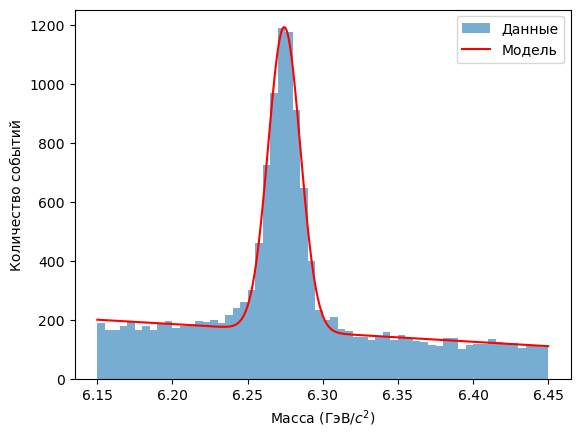

In [103]:
# Построение данных и фита
plt.hist(mass_data, bins= n_bins , range=(low, high), alpha=0.6, label='Данные') # Вместо многоточий укажите число бинов и диапазон

#Создаем массив значений для нашей модели
x_fit = np.linspace(6.15, 6.45, 15000)

#Рисуем модель
plt.plot(x_fit, model(x_fit, *params), 'r-', label='Модель')

#Для удобсва визуализации
plt.xlabel('Масса (ГэВ/$c^2$)')
plt.ylabel('Количество событий')
plt.legend()
plt.show()

Распечатаем оценки параметров функции Гаусса

In [104]:
print(f"Сигнальные события: {N_sig_fit:.0f}  ")
print(f"Фоновые события:  {N_bkg_fit:.0f}  ")
print(f"Оценка μ (масса пика): {mu_fit:.3f}  ГэВ/$c^2$")
print(f"Оценка σ (ширина): {sigma_fit:.3f}  ГэВ/$c^2$")

Сигнальные события: 879  
Фоновые события:  7123  
Оценка μ (масса пика): 6.274  ГэВ/$c^2$
Оценка σ (ширина): 0.011  ГэВ/$c^2$


Поздравляем, если полученное вами число совпало с эталонным ответом на платформе! Конечно, выполняемая оценка сделана крайне грубо ввиду многих особенностей. Как с точки зрения статистики, так и с точки зрения физических особенностей изучаемого процесса. Но, надеюсь, решить данную задачу вам было интересно, а главное полезно для понимания изученной темы.

In [105]:
# 8. Дополнительно: вычисляем значение χ² для оценки качества фита
predictions = model(bin_centers, *params)
chi2 = np.sum(((counts - predictions) ** 2) / predictions)
print(f"χ² = {chi2:.2f}")
print(f"χ²/ndf = {chi2/(len(counts)-len(params)):.2f}")

χ² = 108.28
χ²/ndf = 2.01


# рабочий вариант

Минимальная масса: 6.15
Максимальная масса: 6.45


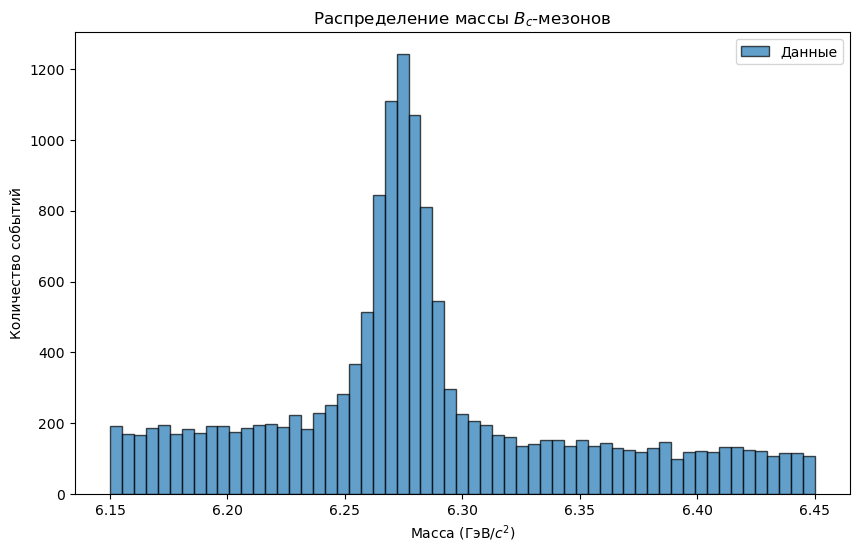

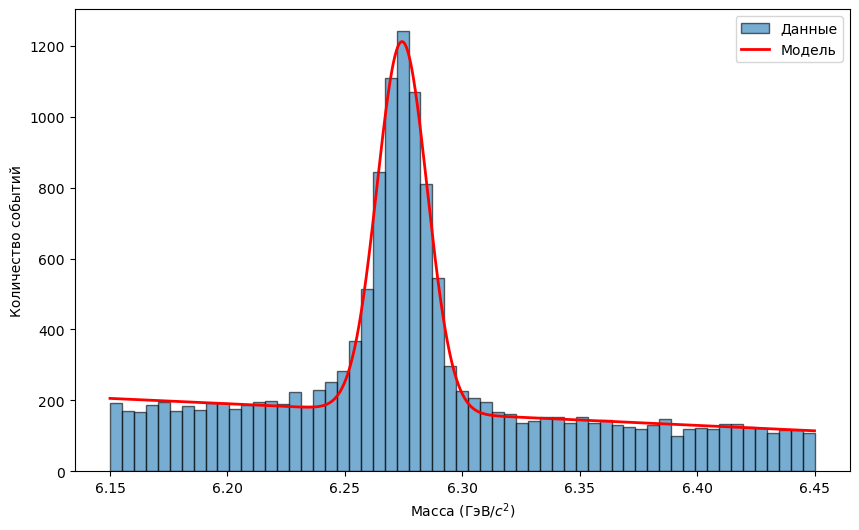

Сигнальные события: 5592
Фоновые события: 7187
Оценка μ (масса пика): 6.274 ГэВ/$c²$
Оценка σ (ширина): 0.011 ГэВ/$c²$
Параметры фона: a = -8.489, b = 57.922
χ² = 113.62
χ²/ndf = 2.14


In [117]:
# 1. Оцениваем интервал, в котором распределены события
min_mass = round(mass_data.min(), 2)
max_mass = round(mass_data.max(), 2)
print(f"Минимальная масса: {min_mass}")
print(f"Максимальная масса: {max_mass}")

# 2. Определяем параметры гистограммы
bin_width = 0.005  # Ширина бина из условия
low = 6.15  # из данных
high = 6.45  # из данных
n_bins = int((high - low) / bin_width)  # ~60 бинов

counts, bin_edges = np.histogram(mass_data, bins=n_bins, range=(low, high))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Визуализация гистограммы
plt.figure(figsize=(10, 6))
plt.hist(mass_data, bins=n_bins, range=(low, high), alpha=0.7, label='Данные', edgecolor='black')
plt.xlabel('Масса (ГэВ/$c^2$)')
plt.ylabel('Количество событий')
plt.title('Распределение массы $B_c$-мезонов')
plt.legend()
plt.show()

# 3. Определяем модель аппроксимации
def model(x, N_sig, N_bkg, mu, sigma, a, b):
    # Сигнальная часть: нормированный Гаусс
    signal = N_sig * (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)
    
    # Фоновая часть: линейная зависимость с свободным членом
    background = N_bkg * (a*x + b)
    
    # Общая модель с поправкой на ширину бина
    return (signal + background) * bin_width

# 4. Определяем начальные приближения параметров
# Из справочника: масса B_c+ = 6274.47 ± 0.32 МэВ/c^2 = 6.27447 ± 0.00032 ГэВ/c^2
mu_value = 6.27447
mu_min = mu_value - 3*0.00032
mu_max = mu_value + 3*0.00032

# Оценка сигма из гистограммы (FWHM ≈ 0.03)
FWHM_estimate = 0.03
sigma_value = FWHM_estimate / 2.355
sigma_min = 0
sigma_max = sigma_value * 2

# Оценка N_sig из высоты пика
peak_height = 1200 # 350  # примерная высота пика из гистограммы
sigma_est = sigma_value
N_sig_value = peak_height * sigma_est * np.sqrt(2*np.pi) / bin_width
N_sig_min = 0
N_sig_max = N_sig_value * 2

# Оценка N_bkg
total_events = len(data)
N_bkg_value = total_events - N_sig_value
N_bkg_min = 0
N_bkg_max = total_events

# Параметры для фона (оставляем как в задании)
params_dict = {
    "N_sig": {"value": N_sig_value, "min": N_sig_min, "max": N_sig_max},
    "N_bkg": {"value": N_bkg_value, "min": N_bkg_min, "max": N_bkg_max},
    "mu": {"value": mu_value, "min": mu_min, "max": mu_max},
    "sigma": {"value": sigma_value, "min": sigma_min, "max": sigma_max},
    "a": {"value": -8, "min": -10, "max": -4},
    "b": {"value": 60, "min": 50, "max": 80},
}

p0 = [params_dict[param]["value"] for param in params_dict]
bounds = (
    [params_dict[param]["min"] for param in params_dict],
    [params_dict[param]["max"] for param in params_dict]
)

# 5. Аппроксимируем
params, _ = curve_fit(model, bin_centers, counts, p0=p0, bounds=bounds, maxfev=5000)
N_sig_fit, N_bkg_fit, mu_fit, sigma_fit, a_fit, b_fit = params

# 6. Визуализация результата
plt.figure(figsize=(10, 6))
plt.hist(mass_data, bins=n_bins, range=(low, high), alpha=0.6, label='Данные', edgecolor='black')

# Создаем массив значений для нашей модели
x_fit = np.linspace(low, high, 1000)

# Рисуем модель
plt.plot(x_fit, model(x_fit, *params), 'r-', label='Модель', linewidth=2)

# Для удобства визуализации
plt.xlabel('Масса (ГэВ/$c^2$)')
plt.ylabel('Количество событий')
plt.legend()
plt.show()

# 7. Выводим результаты
print(f"Сигнальные события: {N_sig_fit:.0f}")
print(f"Фоновые события: {N_bkg_fit:.0f}")
print(f"Оценка μ (масса пика): {mu_fit:.3f} ГэВ/$c²$")
print(f"Оценка σ (ширина): {sigma_fit:.3f} ГэВ/$c²$")
print(f"Параметры фона: a = {a_fit:.3f}, b = {b_fit:.3f}")

# 8. Дополнительно: вычисляем значение χ² для оценки качества фита
predictions = model(bin_centers, *params)
chi2 = np.sum(((counts - predictions) ** 2) / predictions)
print(f"χ² = {chi2:.2f}")
print(f"χ²/ndf = {chi2/(len(counts)-len(params)):.2f}")